# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ResNet-18] Epoch   1/100 | LR: 1.00e-04 | train loss 1.0451 acc 0.562 | val loss 0.6814 acc 0.737 *


[ResNet-18] Epoch   2/100 | LR: 1.00e-04 | train loss 0.6280 acc 0.711 | val loss 0.4998 acc 0.820 *


[ResNet-18] Epoch   3/100 | LR: 1.00e-04 | train loss 0.5472 acc 0.761 | val loss 0.5265 acc 0.780


[ResNet-18] Epoch   4/100 | LR: 1.00e-04 | train loss 0.4701 acc 0.794 | val loss 0.4616 acc 0.817 *


...

[ResNet-18] Epoch  13/100 | LR: 1.00e-04 | train loss 0.2080 acc 0.904 | val loss 0.4091 acc 0.868


[ResNet-18] Epoch  14/100 | LR: 1.00e-04 | train loss 0.2270 acc 0.897 | val loss 0.4401 acc 0.861


[ResNet-18] Epoch  15/100 | LR: 1.00e-05 | train loss 0.2073 acc 0.916 | val loss 0.4478 acc 0.861


[ResNet-18] Epoch  16/100 | LR: 1.00e-05 | train loss 0.1525 acc 0.937 | val loss 0.3847 acc 0.871


[ResNet-18] Epoch  17/100 | LR: 1.00e-05 | train loss 0.1135 acc 0.949 | val loss 0.3939 acc 0.873

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 17.

[ResNet-18] Restored best checkpoint (val loss = 0.3779)


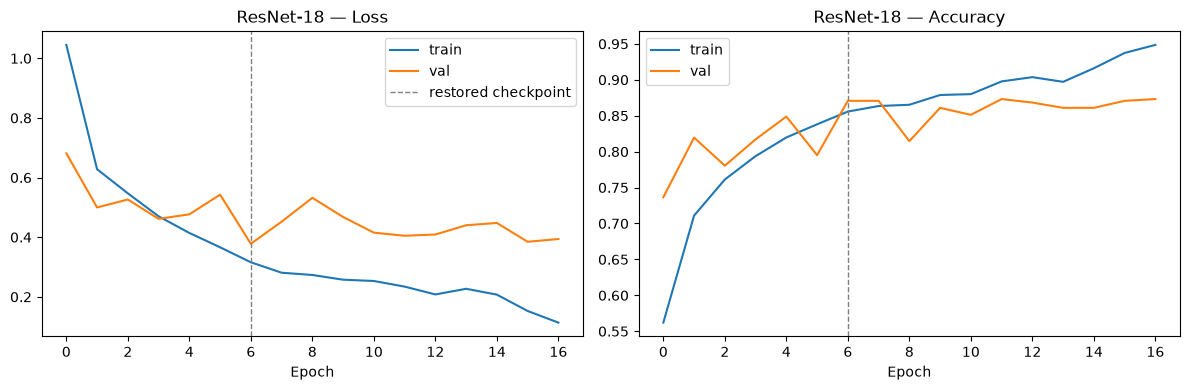

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.793


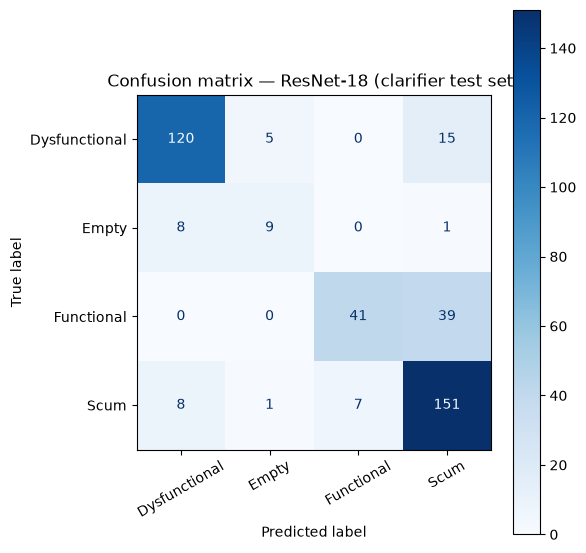

               precision    recall  f1-score   support

Dysfunctional      0.882     0.857     0.870       140
        Empty      0.600     0.500     0.545        18
   Functional      0.854     0.512     0.641        80
         Scum      0.733     0.904     0.810       167

     accuracy                          0.793       405
    macro avg      0.767     0.693     0.716       405
 weighted avg      0.803     0.793     0.785       405



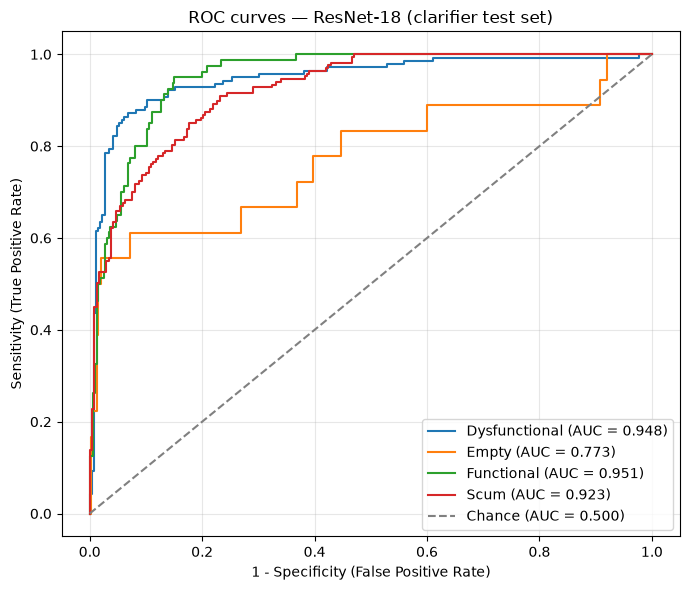

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.948
  Empty          : 0.773
  Functional     : 0.951
  Scum           : 0.923

Mean AUC (over 4/4 classes with test examples): 0.899


(np.float64(0.7925925925925926),
 {'Dysfunctional': 0.9478706199460916,
  'Empty': 0.7730404823428079,
  'Functional': 0.951,
  'Scum': 0.9232123987319478})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_resnet18_cnn.pt
